In [279]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../../QHamSolver/Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe, gue
from tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

from mpl_toolkits.axes_grid1 import make_axes_locatable

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{physics}\usepackage{xcolor}\usepackage{amsmath}\usepackage{amsfonts}'


%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as Gamma
from scipy.special import lambertw
from scipy.special import dawsn as dawson
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists


def base_dir(BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/" + (f"PBC/" if BC else f"OBC/")
    return dirx

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/LGT_Project/FermionQLM/Jupyter_Notebook
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../../QHamSolver/Python/


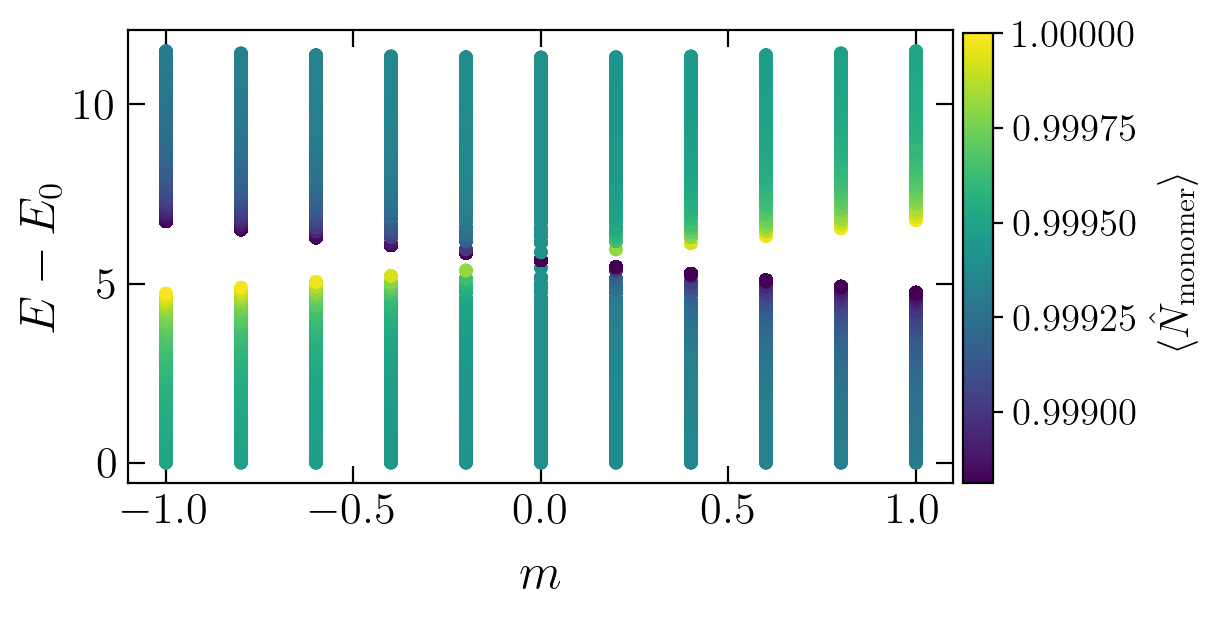

In [140]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1

mass_list = np.arange(-1, 1.1, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=1 - 2*Nd / (Lx * Ly),
                vmax=1 )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

dim = 3 * Lx*Ly
energies = []
monomer_density = []
for iim, mass in enumerate( mass_list ):
    name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('energies'))[0]
            energies.append(E - E[0])
            # energies.append(E - np.mean(E))
            
            x = np.array(file.get('MonomerDensity_states'))[0]
            monomer_density.append(x)
    else:
        print(name)
        energies.append([np.nan] * dim)

energies = np.transpose( np.array(energies) )
monomer_density = np.transpose( np.array(monomer_density) )

for ii, E in enumerate( energies ):
    x = monomer_density[ii]
    # print(x.shape, E.shape)
    axis.scatter(mass_list, E, s=15, color=s_m.to_rgba( monomer_density[ii] ))
    
fig_help.set_plot_elements(axis, ylabel=r"$E-E_0$", xlabel=r"$m$", font_size=16, set_legend=0, xscale='linear', yscale='linear')


fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
cbar.set_label(r"$\langle \hat{N}_{\rm monomer}\rangle$", fontsize=15)
cbar.ax.tick_params(labelsize=14)

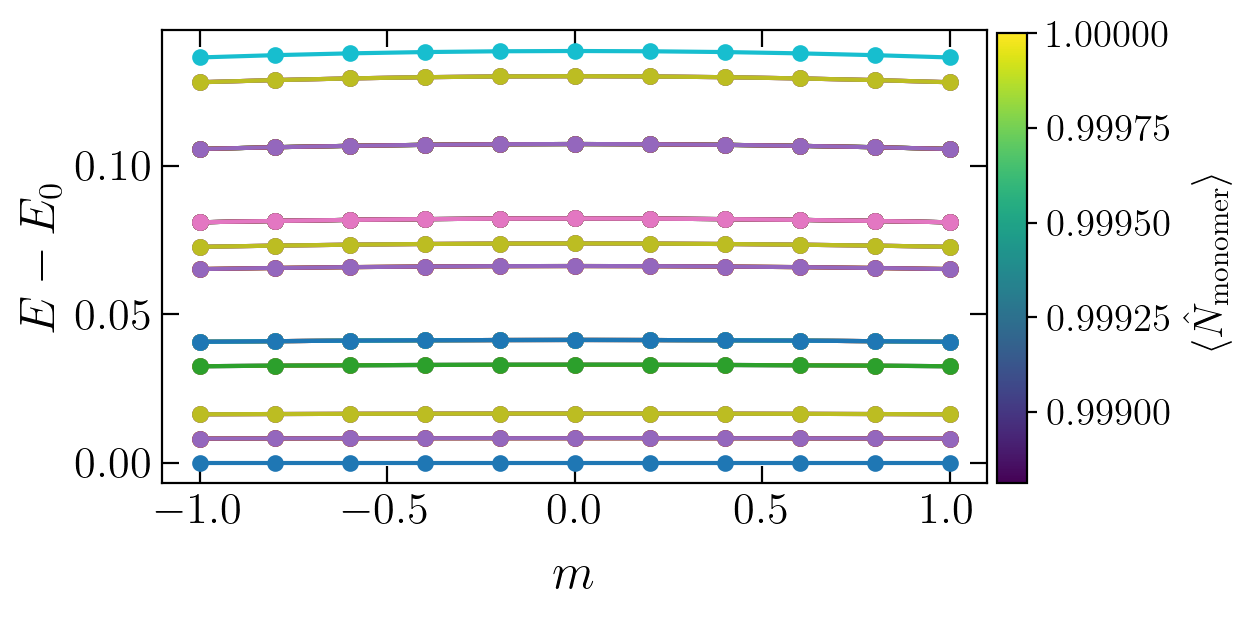

In [143]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1

mass_list = np.arange(-1, 1.1, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=1 - 2*Nd / (Lx * Ly),
                vmax=1 )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

dim = 3 * Lx*Ly

cut = 50
energies = []
monomer_density = []
for iim, mass in enumerate( mass_list ):
    name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('energies'))[0,:cut]
            energies.append(E - E[0])
            # energies.append(E - np.mean(E))
            
            x = np.array(file.get('MonomerDensity_states'))[0,:cut]
            monomer_density.append(x)
    else:
        print(name)
        energies.append([np.nan] * cut)

energies = np.transpose( np.array(energies) )
monomer_density = np.transpose( np.array(monomer_density) )

for ii, E in enumerate( energies ):
    x = monomer_density[ii]
    # print(x.shape, E.shape)
    # axis.scatter(mass_list, E, s=15, color=s_m.to_rgba( monomer_density[ii] ))
    axis.plot(mass_list, E, marker='o', markersize=5)
    
fig_help.set_plot_elements(axis, ylabel=r"$E-E_0$", xlabel=r"$m$", font_size=16, set_legend=0, xscale='linear', yscale='linear')


fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
cbar.set_label(r"$\langle \hat{N}_{\rm monomer}\rangle$", fontsize=15)
cbar.ax.tick_params(labelsize=14)

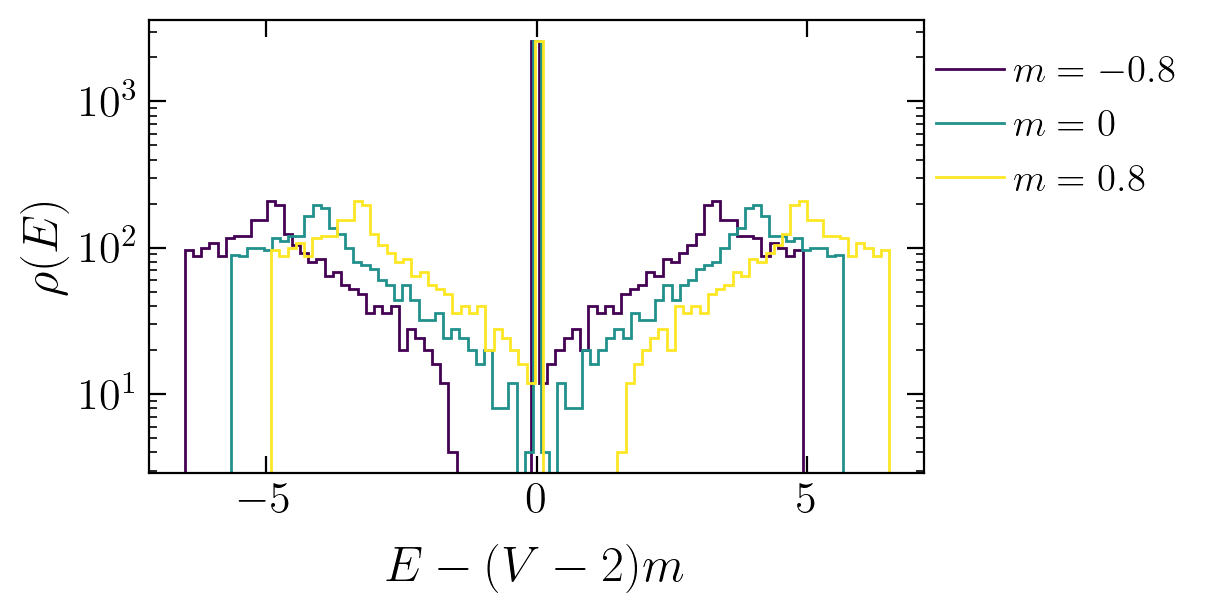

In [307]:
Lx = 51
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1

mass_list = np.arange(-0.8, 1.1, 0.8)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

dim = 3 * Lx*Ly
energies = []
monomer_density = []
for iim, mass in enumerate( mass_list ):
    name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('energies'))[0] - (Lx*Ly-2)*mass
            hist, edge = np.histogram(E, bins=75)
            axis.stairs(hist, edge, color=s_m.to_rgba(mass), label=r"$m=%g$"%mass if np.abs(mass) > 0 else r"$m=0$")
    else:
        print(name)

fig_help.set_plot_elements(axis, ylabel=r"$\rho(E)$", xlabel=r"$E-(V-2)m$", font_size=16, set_legend=0, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=14, loc='upper left', anchor=(0.97, 1.0), frameon=False)

# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
# cbar.set_label(r"$m$", fontsize=15)
# cbar.ax.tick_params(labelsize=14)

In [326]:
8 * 8 *4304096 * 3 / 1e9

0.826386432

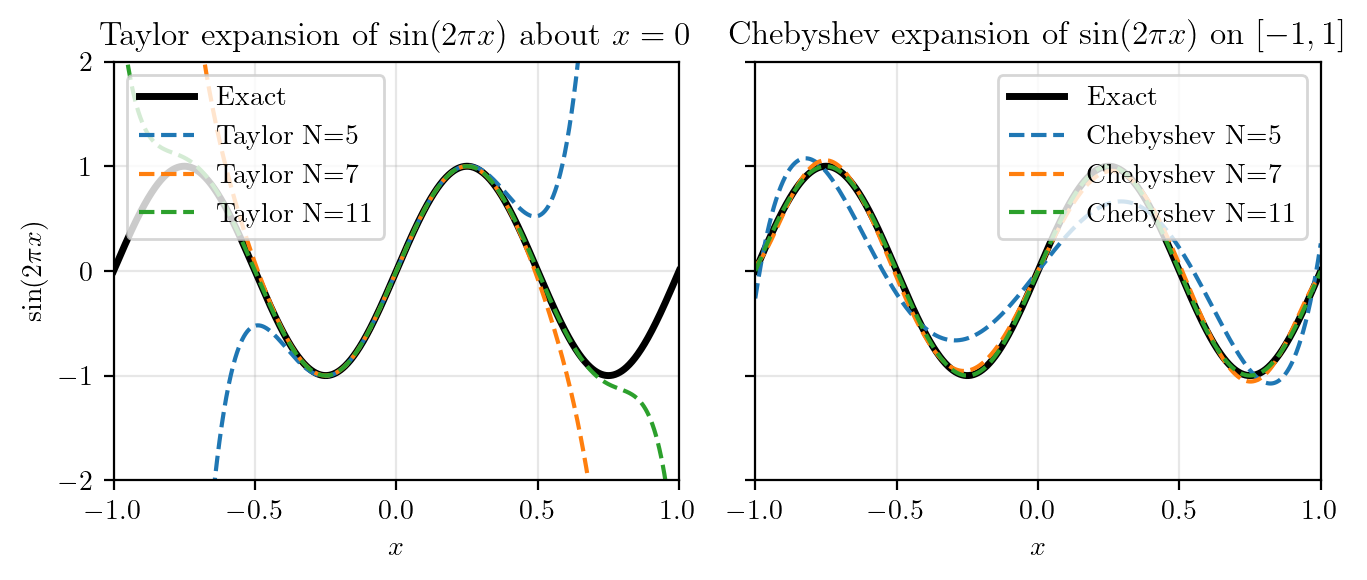

In [331]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from scipy.special import jv   # Bessel functions J_n

# Function to approximate
def f(x):
    return np.sin(2 * np.pi * x)

# Maclaurin/Taylor expansion of sin(2*pi*x) about x = 0
def taylor_sin_2pix(x, N):
    """
    Taylor polynomial of sin(2*pi*x) up to degree N.
    """
    result = np.zeros_like(x)
    for k in range((N // 2) + 1):
        power = 2 * k + 1
        if power <= N:
            result += ((-1)**k) * (2 * np.pi * x)**power / factorial(power)
    return result

# Chebyshev expansion of sin(2*pi*x)
def chebyshev_sin_2pix(x, N):
    """
    Chebyshev expansion of sin(2*pi*x) up to order N.

    Uses:
        sin(z x) = 2 sum_{m=0}^\infty (-1)^m J_{2m+1}(z) T_{2m+1}(x)

    with z = 2*pi.
    """
    z = 2 * np.pi
    result = np.zeros_like(x)

    for n in range(N + 1):
        if n % 2 == 1:  # only odd Chebyshev polynomials contribute
            m = (n - 1) // 2
            coeff = 2 * ((-1)**m) * jv(n, z)
            Tn = np.polynomial.chebyshev.chebval(
                x, [0]*n + [1]
            )
            result += coeff * Tn

    return result

# Grid on [-1, 1]
x = np.linspace(-1, 1, 1000)
y_exact = f(x)

# Approximation orders
orders = [5, 7, 11]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True, dpi=200)

# Left panel: Taylor approximations
axes[0].plot(x, y_exact, 'k', linewidth=2.5, label="Exact")
for N in orders:
    axes[0].plot(
        x,
        taylor_sin_2pix(x, N),
        linewidth=1.5, ls='--', 
        label=f"Taylor N={N}"
    )

axes[0].set_title(r"Taylor expansion of $\sin(2\pi x)$ about $x=0$")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$\sin(2\pi x)$")
axes[0].set_xlim(-1, 1)
axes[0].set_ylim(-2, 2)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right panel: Chebyshev approximations
axes[1].plot(x, y_exact, 'k', linewidth=2.5, label="Exact")
for N in orders:
    axes[1].plot(
        x,
        chebyshev_sin_2pix(x, N),
        linewidth=1.5, ls='--', 
        label=f"Chebyshev N={N}"
    )

axes[1].set_title(r"Chebyshev expansion of $\sin(2\pi x)$ on $[-1,1]$")
axes[1].set_xlabel(r"$x$")
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(-2, 2)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
fig.savefig("Fig_Cheb.pdf", bbox_inches = 'tight', pad_inches=0.02)

## SPIN-$\downarrow$ dynamics

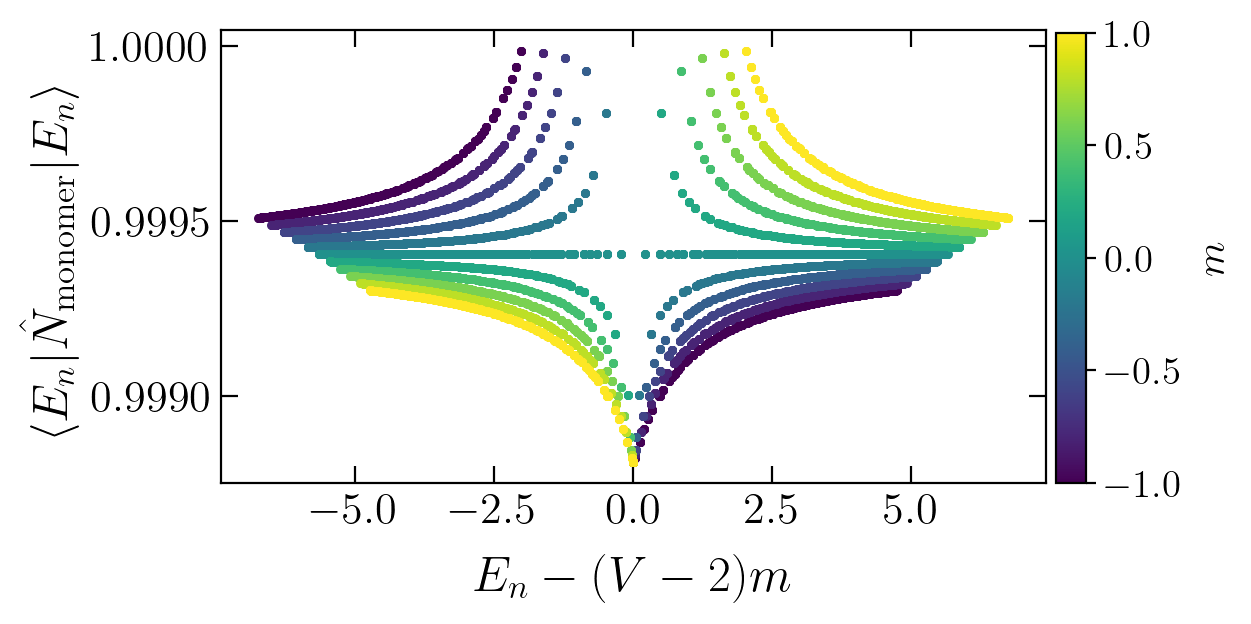

In [149]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1

mass_list = np.arange(-1, 1.1, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

dim = 3 * Lx*Ly
energies = []
monomer_density = []
for iim, mass in enumerate( mass_list ):
    name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('energies'))[0]
            # E = (E - E[0]) / (E[-1] - E[0])
            # E = E - np.mean(E)
            E = E - (Lx*Ly-2)*mass
            Nmono = np.array(file.get('MonomerDensity_states'))[0]
            
            # axis.plot(E, Nmono, marker='o', color=s_m.to_rgba(mass), markersize=4, lw=0.5)
            axis.scatter(E, Nmono, marker='o', color=s_m.to_rgba(mass), s=5)
    else:
        print(name)

fig_help.set_plot_elements(axis, ylabel=r"$\langle E_n|\hat{N}_{\rm monomer}|E_n\rangle$", xlabel=r"$E_n-(V-2)m$", font_size=16, set_legend=0, xscale='linear', yscale='linear')


fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
cbar.set_label(r"$m$", fontsize=15)
cbar.ax.tick_params(labelsize=14)

In [147]:
41*41

1681

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


4


Text(0.5, 1.0, '$\\langle \\hat{n}_{\\rm dimer}\\rangle$')

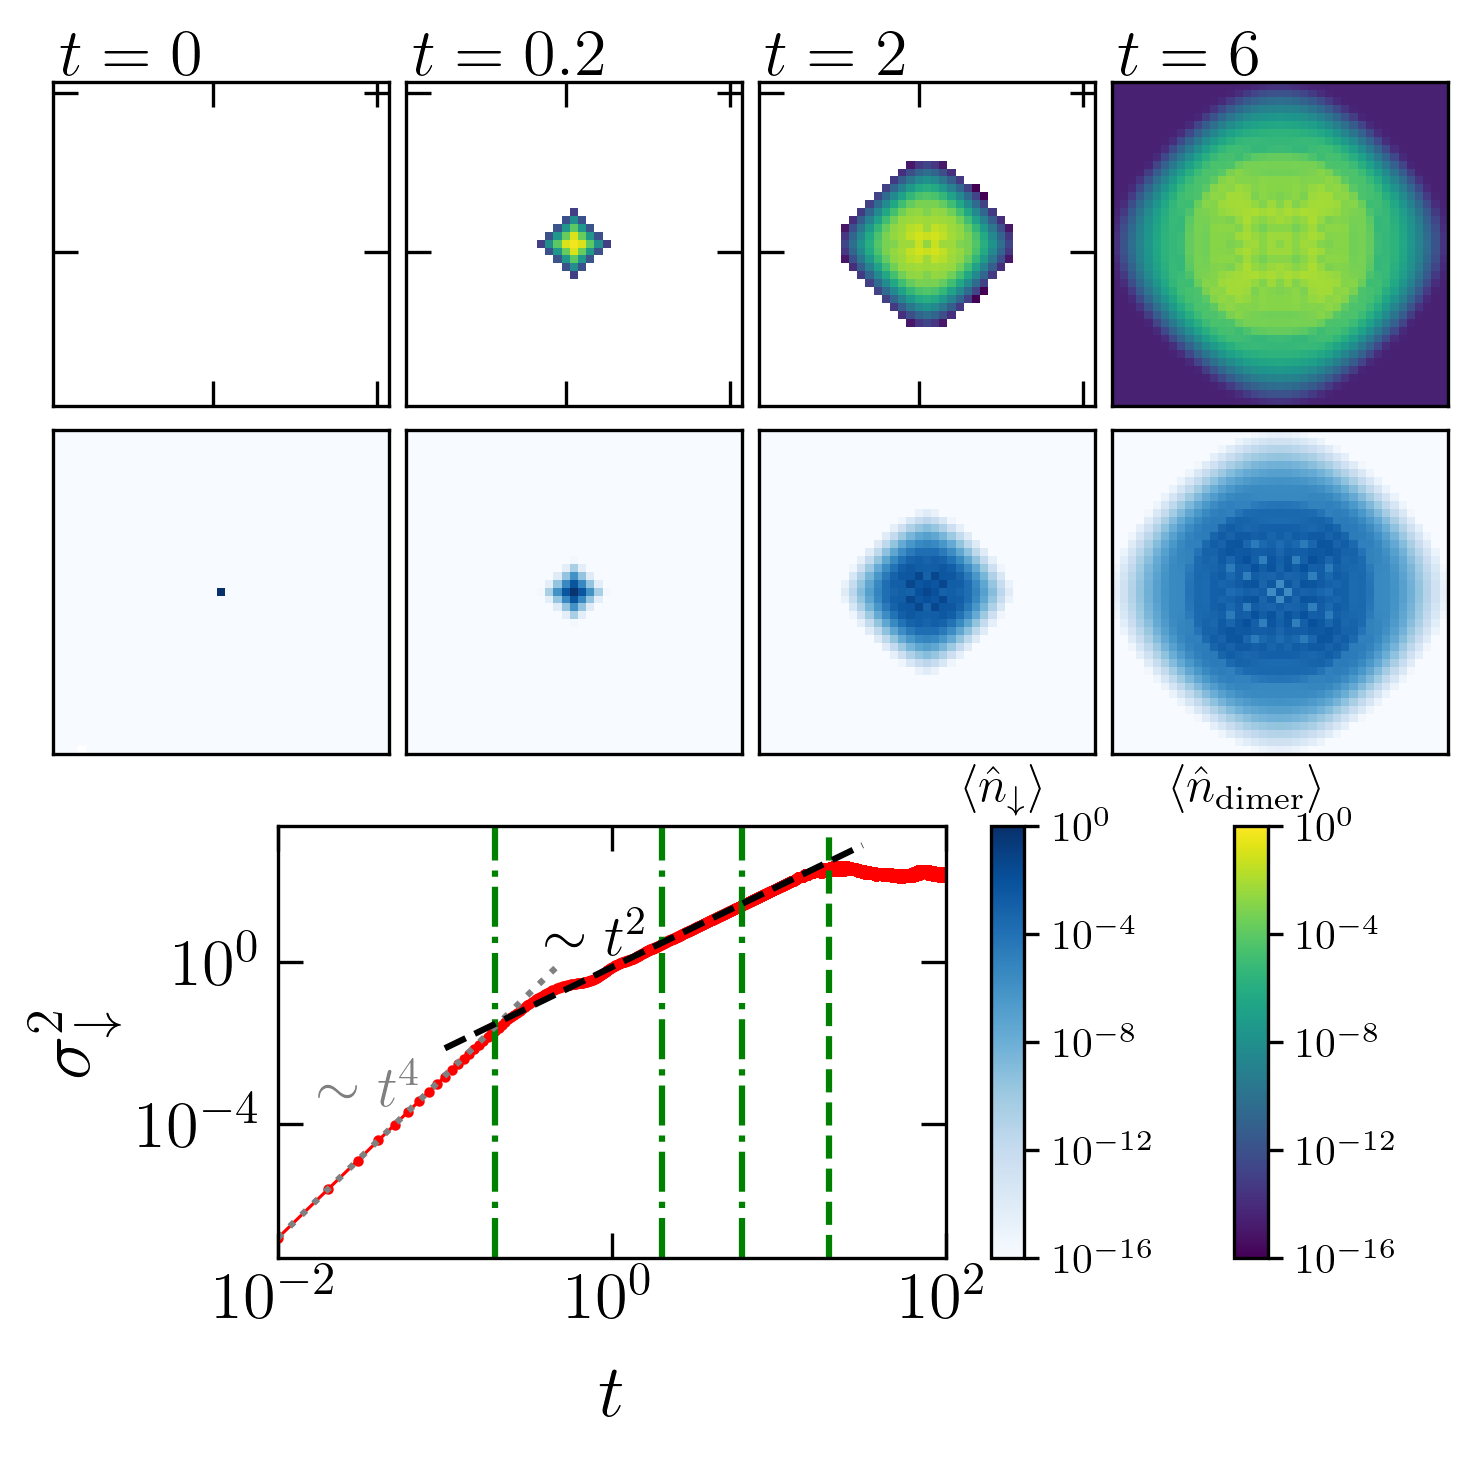

In [323]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1


# fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)


fig = plt.figure(figsize=(6,4), dpi = 300)

gs1 = GridSpec(1, 1)
gs1.update(top=0.38, bottom=0.02, left=0.25, right=0.8)
axis = fig.add_subplot(gs1[0,0])

gs2 = GridSpec(1, 4)
gs2.update(top=0.71, bottom=0.44, wspace=0.05, hspace=0.05)
ax = []
_ax0 = fig.add_subplot(gs2[0]);  ax.append(_ax0)
_ax1 = fig.add_subplot(gs2[1], sharey = _ax0, sharex = _ax0); ax.append(_ax1)
_ax2 = fig.add_subplot(gs2[2], sharey = _ax0, sharex = _ax0); ax.append(_ax2)
_ax3 = fig.add_subplot(gs2[3], sharey = _ax0, sharex = _ax0); ax.append(_ax3)

gs3 = GridSpec(1, 4)
gs3.update(top=1, bottom=0.73, wspace=0.05, hspace=0.05)
ax2 = []
_ax0 = fig.add_subplot(gs3[0]);ax2.append(_ax0)
_ax1 = fig.add_subplot(gs3[1], sharey = _ax0, sharex = _ax0); ax2.append(_ax1)
_ax2 = fig.add_subplot(gs3[2], sharey = _ax0, sharex = _ax0); ax2.append(_ax2)
_ax3 = fig.add_subplot(gs3[3], sharey = _ax0, sharex = _ax0); ax2.append(_ax3)

print( len(ax) )
dim = 3 * Lx*Ly
mass = -1

X = np.arange(1, Lx+1, 1)
plot_times = [0, 0.2, 2, 6.0]
name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
if exists(name):
    with h5py.File(name, "r") as file:
        times = np.array(file.get('times'))[0,1:]
        sigma = np.array(file.get('spreading'))[0,1:]
        axis.plot(times, sigma, color='red', marker='o', markersize=1.5, lw=0.75)
        for iit, t in enumerate( plot_times ):
            if t > 0:
                axis.axvline(x=t, color='green', ls='-.')
            n = order_of_magnitude( np.abs(t) )
            SpinDown = np.array(file.get('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n))))
            # SpinDown = 1 - np.array(file.get('MonomerDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n))))
            # print('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n)))
            # norms = matplotlib.colors.LogNorm(vmin=np.min(SpinDown.flatten()), vmax=np.max(SpinDown.flatten()))
            # p = ax[iit].pcolormesh(X, X, SpinDown, shading='nearest', cmap='Blues', norm=norms)
            p1 = ax[iit].pcolormesh(X, X, SpinDown, shading='nearest', cmap='Blues', norm=matplotlib.colors.LogNorm(vmin=1e-16, vmax=1))
            
            Monomers = 1 - np.array(file.get('MonomerDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n))))
            p2 = ax2[iit].pcolormesh(X, X, Monomers, shading='nearest', cmap='viridis', norm=matplotlib.colors.LogNorm(vmin=1e-16, vmax=1))
else:
    print(name)

fig_help.set_plot_elements(axis, ylabel=r"$\sigma^2_\downarrow$", xlabel=r"$t$", font_size=16, set_legend=0, xscale='log', yscale='log')
axis.axvline(x=20, color='green', ls='--')

x = np.logspace(-2, -0.3, 1000)
axis.plot(x, 16*x**4, ls=':', color='gray')
axis.annotate(r"$\sim t^4$", fontsize=14, xy=(0.06, 0.35), xycoords='axes fraction', color='gray')

x = np.logspace(-1, 1.5, 1000)
axis.plot(x, 0.75 * x**2, ls='--', color='black')
axis.annotate(r"$\sim t^2$", fontsize=14, xy=(0.4, 0.7), xycoords='axes fraction', color='k')

axis.set_xlim(min(times), max(times))
for iiax, a in enumerate(ax):
    fig_help.set_plot_elements(a, ylabel=r"", xlabel=r"", font_size=14)
    a.tick_params(axis='x', which='both',labelbottom=False,labeltop=False)
    a.tick_params(axis='y', which='both',labelleft=False,labelright=False)

divider = make_axes_locatable(axis)  # last axis
cax = divider.append_axes("right", size="5%", pad=0.15)
fig.colorbar(p1, cax=cax)#, title=r"$1-\langle \hat{N}_{\rm mon}\rangle$")
cax.set_title(r"$\langle \hat{n}_{\downarrow}\rangle$")

for iiax, a in enumerate(ax2):
    fig_help.set_plot_elements(a, ylabel=r"", xlabel=r"", font_size=14)
    a.tick_params(axis='x', which='both',labelbottom=False,labeltop=False)
    a.tick_params(axis='y', which='both',labelleft=False,labelright=False)
    a.annotate(r"$t=%g$"%plot_times[iiax], fontsize=16, xy=(0.02, 1.02), xycoords='axes fraction', color='k')

# divider = make_axes_locatable(axis)  # last axis
cax = divider.append_axes("right", size="5%", pad=0.7)
fig.colorbar(p2, cax=cax)#, title=r"$1-\langle \hat{N}_{\rm mon}\rangle$")
cax.set_title(r"$\langle \hat{n}_{\rm dimer}\rangle$")
# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
# cbar.set_label(r"$m$", fontsize=15)
# cbar.ax.tick_params(labelsize=14)

In [325]:
binom(36, 8) * 36

1089372240.0

(0.01, 100.0)

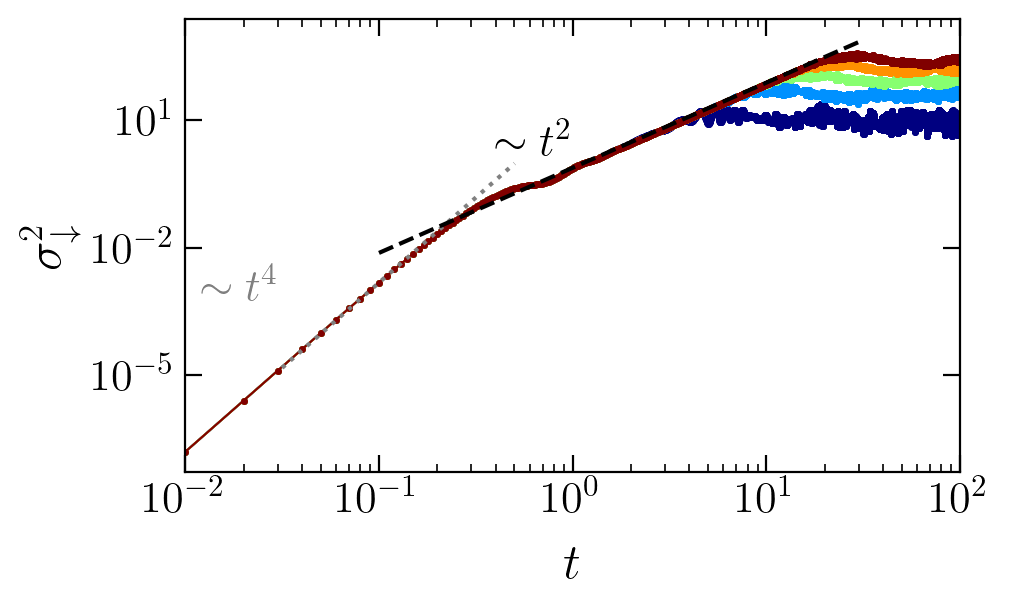

In [260]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

mass_list = np.arange(-1, 1.1, 0.2)
sizes = [10, 21, 31, 41, 51]
norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

dim = 3 * Lx*Ly
mass = -1

X = np.arange(1, Lx+1, 1)
plot_times = [0, 1, 2, 6]
mass = -1
for Lx in sizes:
    Ly = Lx
    col = s_m.to_rgba(Lx)
    name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
    if exists(name):
        with h5py.File(name, "r") as file:
            times = np.array(file.get('times'))[0,1:]
            sigma = np.array(file.get('spreading'))[0,1:]
            axis.plot(times, sigma, color=col, marker='o', markersize=1.5, lw=0.75)
    else:
        print(name)

fig_help.set_plot_elements(axis, ylabel=r"$\sigma^2_{\downarrow}$", xlabel=r"$t$", font_size=16, set_legend=0, xscale='log', yscale='log')

x = np.logspace(-1.5, -0.3, 1000)
axis.plot(x, 15*x**4, ls=':', color='gray')
axis.annotate(r"$\sim t^4$", fontsize=16, xy=(0.02, 0.38), xycoords='axes fraction', color='gray')

x = np.logspace(-1, 1.5, 1000)
axis.plot(x, 0.75 * x**2, ls='--', color='black')
axis.annotate(r"$\sim t^2$", fontsize=16, xy=(0.4, 0.7), xycoords='axes fraction', color='k')

axis.set_xlim(min(times), max(times))


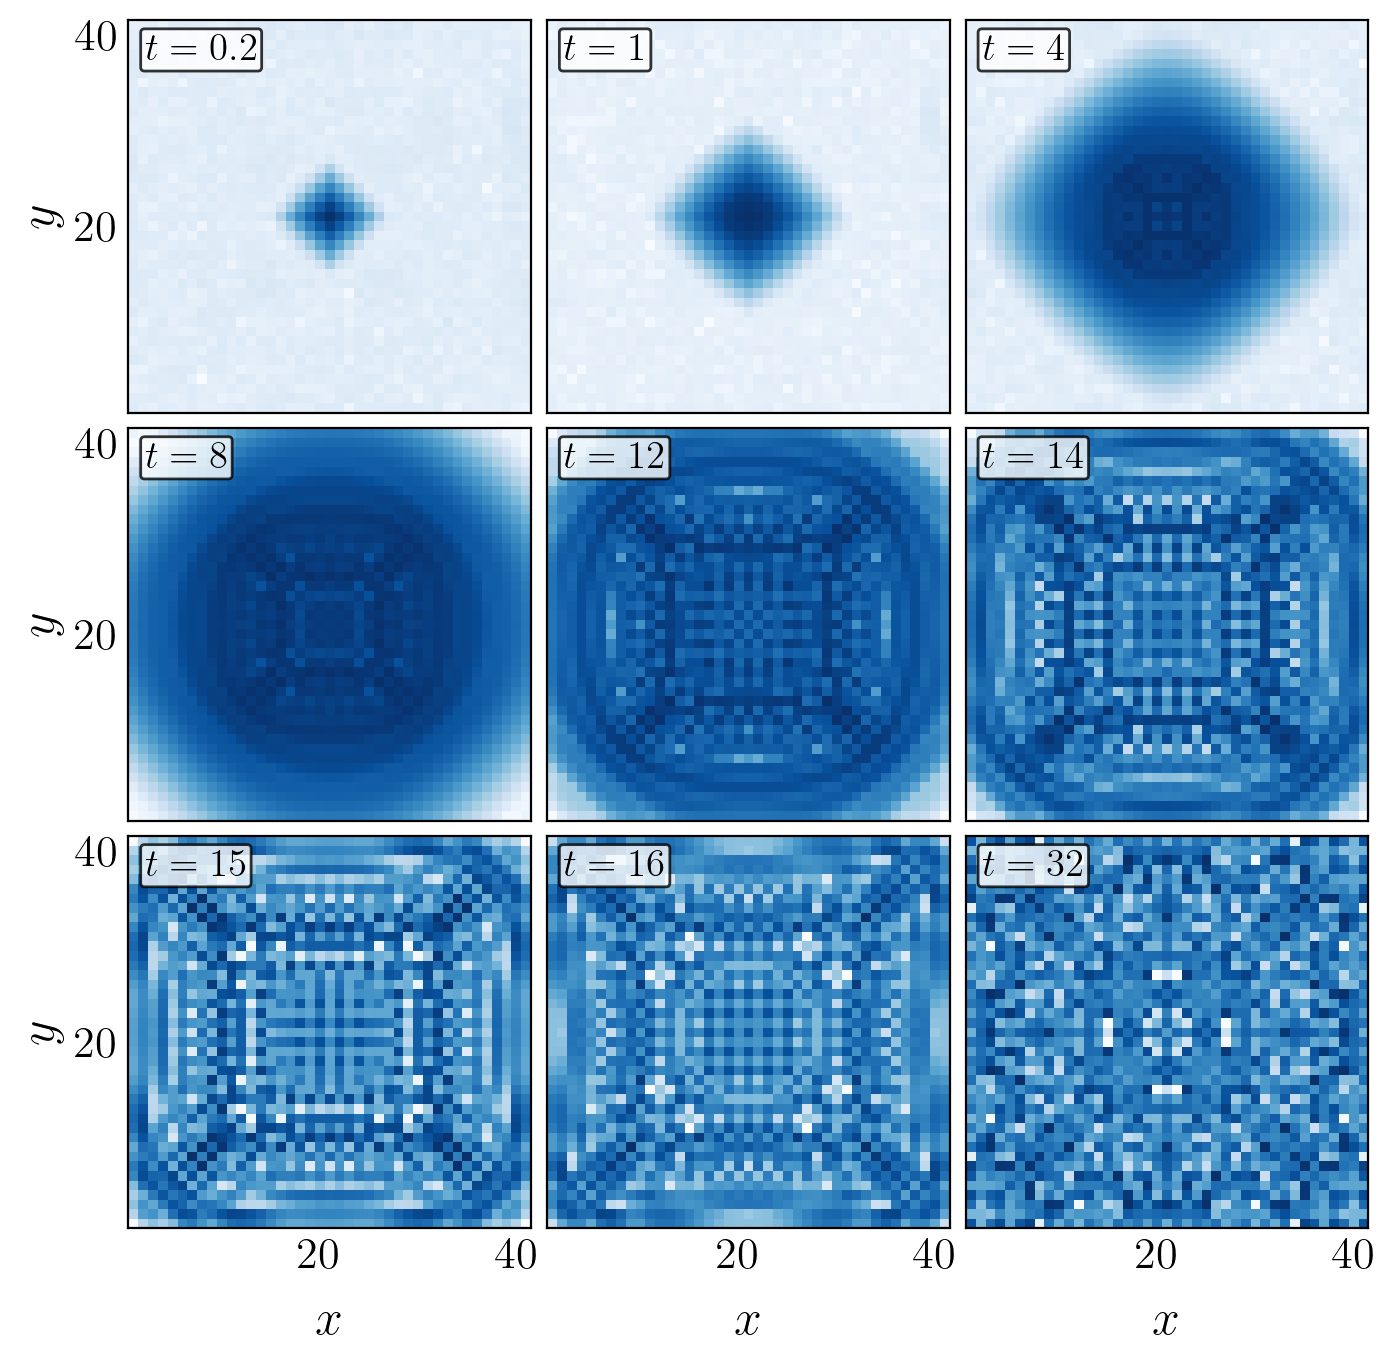

In [169]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1


fig, axis = plt.subplots( nrows=3, ncols=3, figsize=(8,8), dpi = 200, sharex=True, sharey=True)
axis = axis.flatten()
dim = 3 * Lx*Ly
mass = -1

t = 10

X = np.arange(1, Lx+1, 1)

mass_list = np.arange(-1, 0.7, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

mass = -1
name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
if exists(name):
    with h5py.File(name, "r") as file:
        plot_times = [0.2, 1, 4, 8, 12, 14, 15, 16, 32]
        for iit, t in enumerate( plot_times ):
            n = order_of_magnitude( np.abs(t) )
            SpinDown = np.array(file.get('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n))))
            # print('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n)))
            norms = matplotlib.colors.LogNorm(vmin=np.min(SpinDown.flatten()), vmax=np.max(SpinDown.flatten()))
            p = axis[iit].pcolormesh(X, X, SpinDown, shading='nearest', cmap='Blues', norm=norms)
            # p = axis[iim].pcolormesh(X, X, SpinDown, shading='nearest', cmap='Blues', norm=matplotlib.colors.LogNorm(vmin=1e-16, vmax=1))
            fig_help.set_plot_elements(axis[iit], ylabel=r"$y$" if iit%3 ==0 else "", xlabel=r"$x$" if iit >5 else "", font_size=16, set_legend=0, xscale='linear', yscale='linear')
else:
    print(name)


for iiax, a in enumerate(axis):
    t = plot_times[iiax]
    # a.annotate(r"$t=%g$"%t, fontsize=12, xy=(0.02, 0.93), xycoords='axes fraction', color='k')
    a.annotate(r"$t=%g$"%plot_times[iiax], 
           fontsize=14, 
           xy=(0.04, 0.9), 
           xycoords='axes fraction', 
           color='k',
           bbox=dict(boxstyle="round,pad=0.1", 
                     facecolor='white', 
                     edgecolor='black', 
                     alpha=0.8))
    
# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
# cbar.set_label(r"$m$", fontsize=15)
# cbar.ax.tick_params(labelsize=14)

fig.subplots_adjust(wspace = 0.04, hspace=0.04)

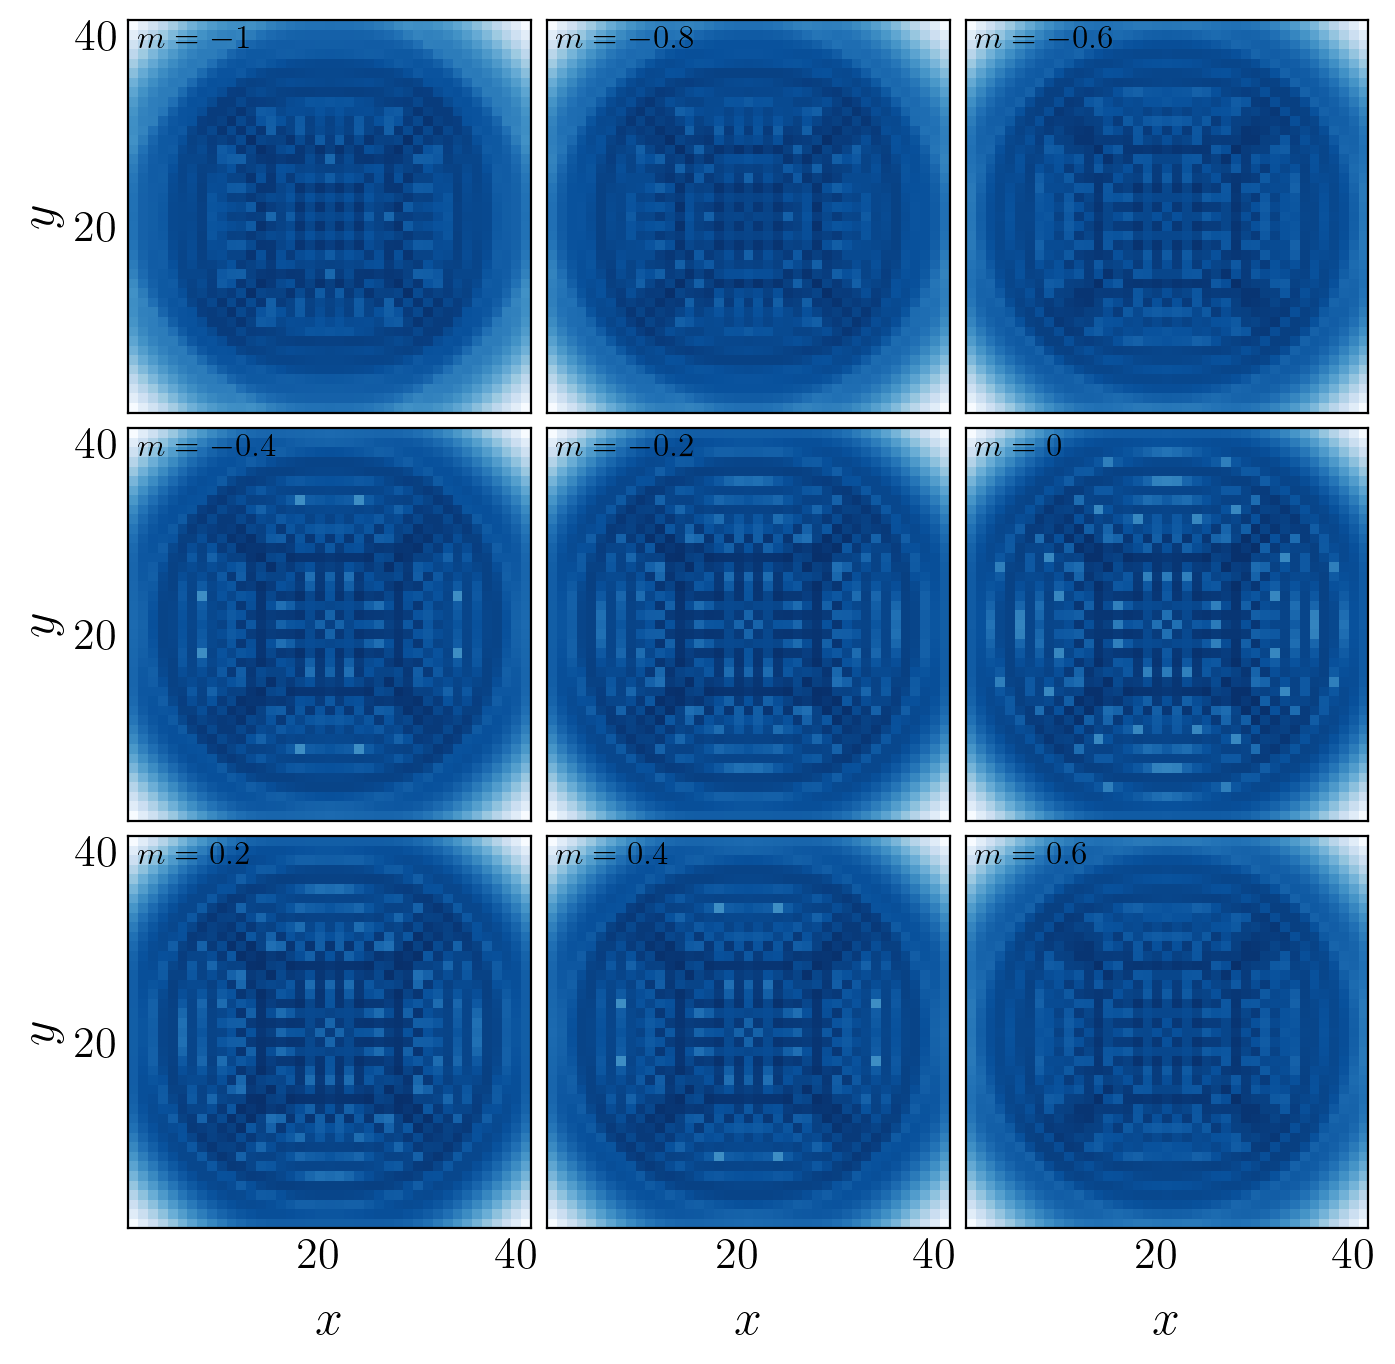

In [161]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1


fig, axis = plt.subplots( nrows=3, ncols=3, figsize=(8,8), dpi = 200, sharex=True, sharey=True)
axis = axis.flatten()
dim = 3 * Lx*Ly
mass = -1

t = 10

X = np.arange(1, Lx+1, 1)

mass_list = np.arange(-1, 0.7, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

for iim, mass in enumerate(mass_list):
    name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
    if exists(name):
        with h5py.File(name, "r") as file:
            n = order_of_magnitude( np.abs(t) )
            SpinDown = np.array(file.get('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n))))
            # print('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n)))
            norms = matplotlib.colors.LogNorm(vmin=np.min(SpinDown.flatten()), vmax=np.max(SpinDown.flatten()))
            p = axis[iim].pcolormesh(X, X, SpinDown, shading='nearest', cmap='Blues', norm=norms)
            # p = axis[iim].pcolormesh(X, X, SpinDown, shading='nearest', cmap='Blues', norm=matplotlib.colors.LogNorm(vmin=1e-16, vmax=1))
    else:
        print(name)

    fig_help.set_plot_elements(axis[iim], ylabel=r"$y$" if iim%3 ==0 else "", xlabel=r"$x$" if iim >5 else "", font_size=16, set_legend=0, xscale='linear', yscale='linear')

for iiax, a in enumerate(axis):
    mass = mass_list[iiax]
    a.annotate(r"$m=%g$"%mass if np.abs(mass) > 1e-14 else r"$m=0$", fontsize=12, xy=(0.02, 0.93), xycoords='axes fraction', color='k')
    
# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
# cbar.set_label(r"$m$", fontsize=15)
# cbar.ax.tick_params(labelsize=14)

fig.subplots_adjust(wspace = 0.04, hspace=0.04)

No handles with labels found to put in legend.


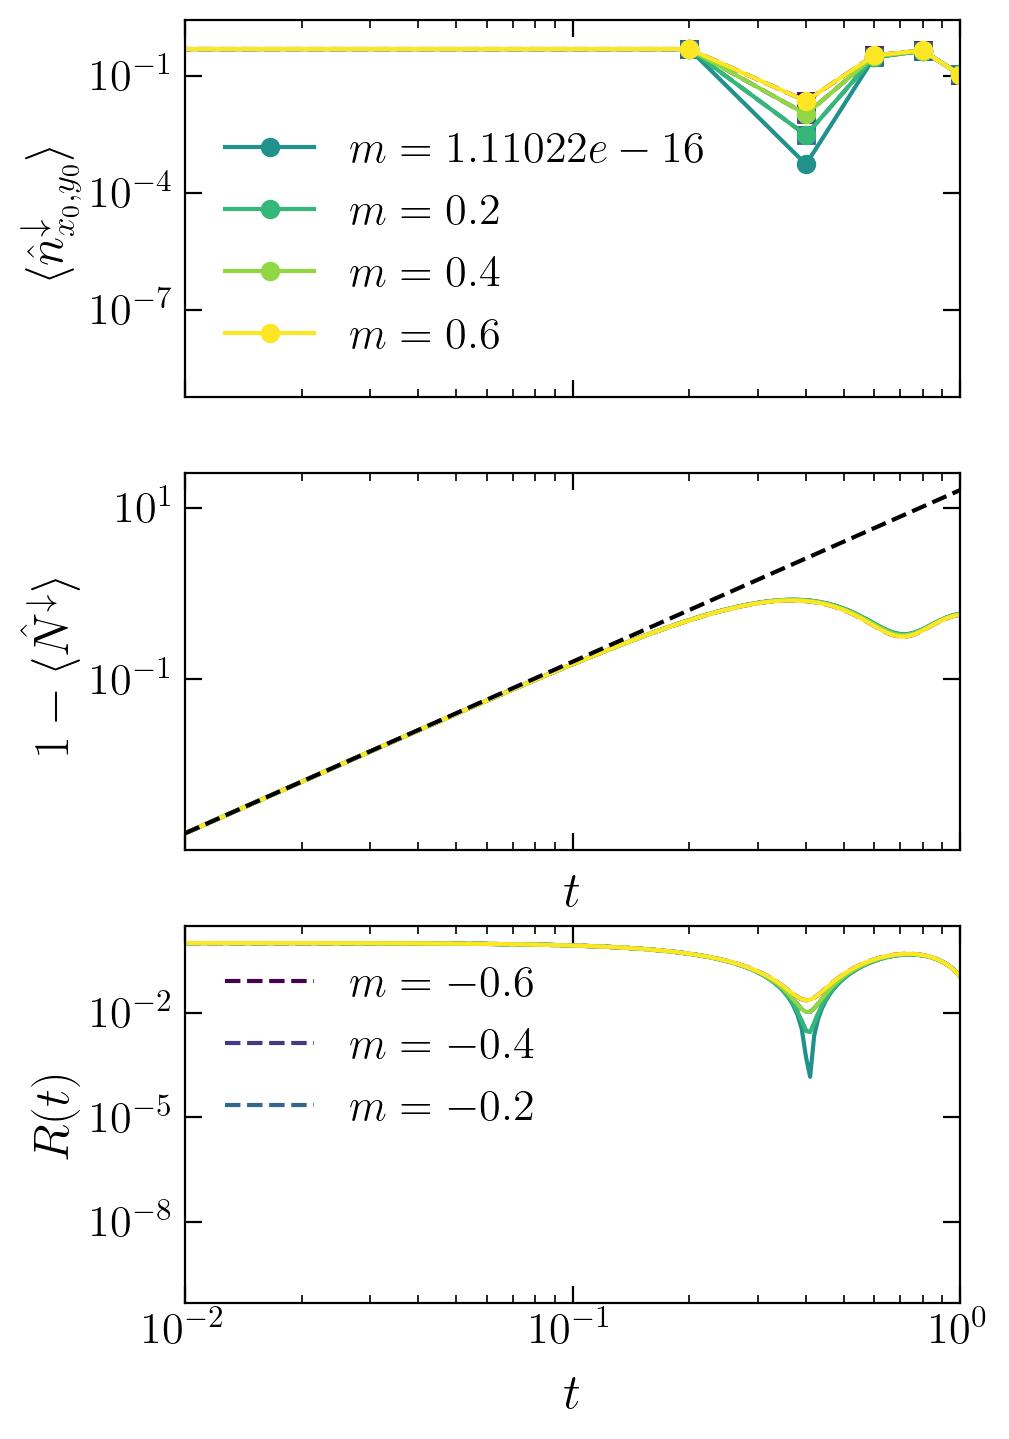

In [322]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1

mass_list = np.arange(-0.6, 0.7, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=3, ncols=1, figsize=(5,8.5), dpi = 200, sharex=True)

dim = 3 * Lx*Ly

for iim, mass in enumerate( mass_list ):
    col = s_m.to_rgba(mass)
    name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
    if exists(name):
        with h5py.File(name, "r") as file:
            
            times = np.array(file.get('times'))[0,1:]
            return_probability = np.array(file.get('return_probability'))[0,1:]
            axis[2].plot(times, return_probability, color=col, label=r"$m=%g$"%mass if mass < 0 else "", ls='-' if mass > 0 else '--')
            
            SpinDownNumber = np.array(file.get('SpinDownDensity'))[0,1:]
            axis[1].plot(times, 1-Lx*Ly * SpinDownNumber, color=col, ls='-' if mass > 0 else '--')
            # SpinUpNumber = np.array(file.get('MonomerDensity'))[0,1:] - SpinDownNumber
            # axis[1].plot(times, Lx*Ly * SpinUpNumber / (Lx*Ly-1), color=col, ls='--')
            
            plot_times = np.arange(0, max(times), 0.2)
            spindown_density = np.zeros(plot_times.shape)
            for iit, t in enumerate( plot_times ):
                spindown_density[0] = 1
                if t > 0:
                    n = order_of_magnitude( np.abs(t) )
                    spindown_density[iit] = np.array(file.get('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n))))[Ly//2, Lx//2]
            axis[0].plot(plot_times, spindown_density, color=col, marker='o' if mass > 0 else 's', label=r"$m=%g$"%mass if mass >= 0 else "", ls='-' if mass > 0 else '--')
    else:   
        print(name)

fig_help.set_plot_elements(axis[0], ylabel=r"$\langle \hat{n}^{\downarrow}_{x_0,y_0}\rangle$", xlabel=r"", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$1-\langle \hat{N}^{\downarrow}\rangle$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_plot_elements(axis[2], ylabel=r"$R(t)$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')
axis[0].set_xlim(1e-2, 1e0)
axis[1].axvline(x=20, ls='-', color='k')

z = np.logspace(-2, 0, 100)
axis[1].plot(z, 16*z**2, ls='--', color='k')
# axis[1].plot(z, 100*z**4, ls=':', color='gray')
# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
# cbar.set_label(r"$m$", fontsize=15)
# cbar.ax.tick_params(labelsize=14)

## DIMER DYNAMICS

(0.05, 50.0)

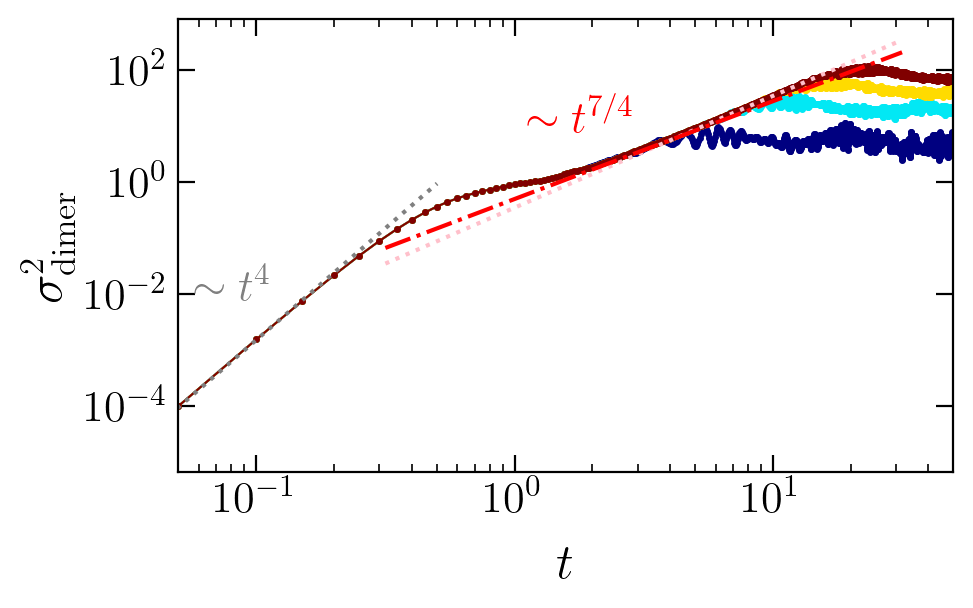

In [258]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

mass_list = np.arange(-1, 1.1, 0.2)
sizes = [10, 21, 31, 41]
norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

dim = 3 * Lx*Ly
mass = -1

X = np.arange(1, Lx+1, 1)
plot_times = [0, 1, 2, 6]
mass = -1
for Lx in sizes:
    Ly = Lx
    col = s_m.to_rgba(Lx)
    name = base_dir(BC) + "DimerDynamics_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
    if exists(name):
        with h5py.File(name, "r") as file:
            times = np.array(file.get('times'))[0,1:]
            sigma = np.array(file.get('spreading'))[0,1:]
            axis.plot(times, sigma, color=col, marker='o', markersize=1.5, lw=0.75)
    else:
        print(name)

fig_help.set_plot_elements(axis, ylabel=r"$\sigma^2_{\rm dimer}$", xlabel=r"$t$", font_size=16, set_legend=0, xscale='log', yscale='log')

x = np.logspace(-1.5, -0.3, 1000)
axis.plot(x, 15*x**4, ls=':', color='gray')
axis.annotate(r"$\sim t^4$", fontsize=16, xy=(0.02, 0.38), xycoords='axes fraction', color='gray')

x = np.logspace(-0.5, 1.5, 1000)

axis.plot(x, 0.35 * x**2, ls=':', color='pink')
# axis.annotate(r"$\sim t^2$", fontsize=16, xy=(0.35, 0.75), xycoords='axes fraction', color='k')

# x = np.logspace(0., 1., 1000)
axis.plot(x, 0.5 * x**1.75, ls='-.', color='red')
axis.annotate(r"$\sim t^{7/4}$", fontsize=16, xy=(0.45, 0.75), xycoords='axes fraction', color='red')

axis.set_xlim(min(times), max(times))


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


Text(0, 0.5, '$ 1-\\langle \\hat{N}_{\\rm mon}\\rangle$')

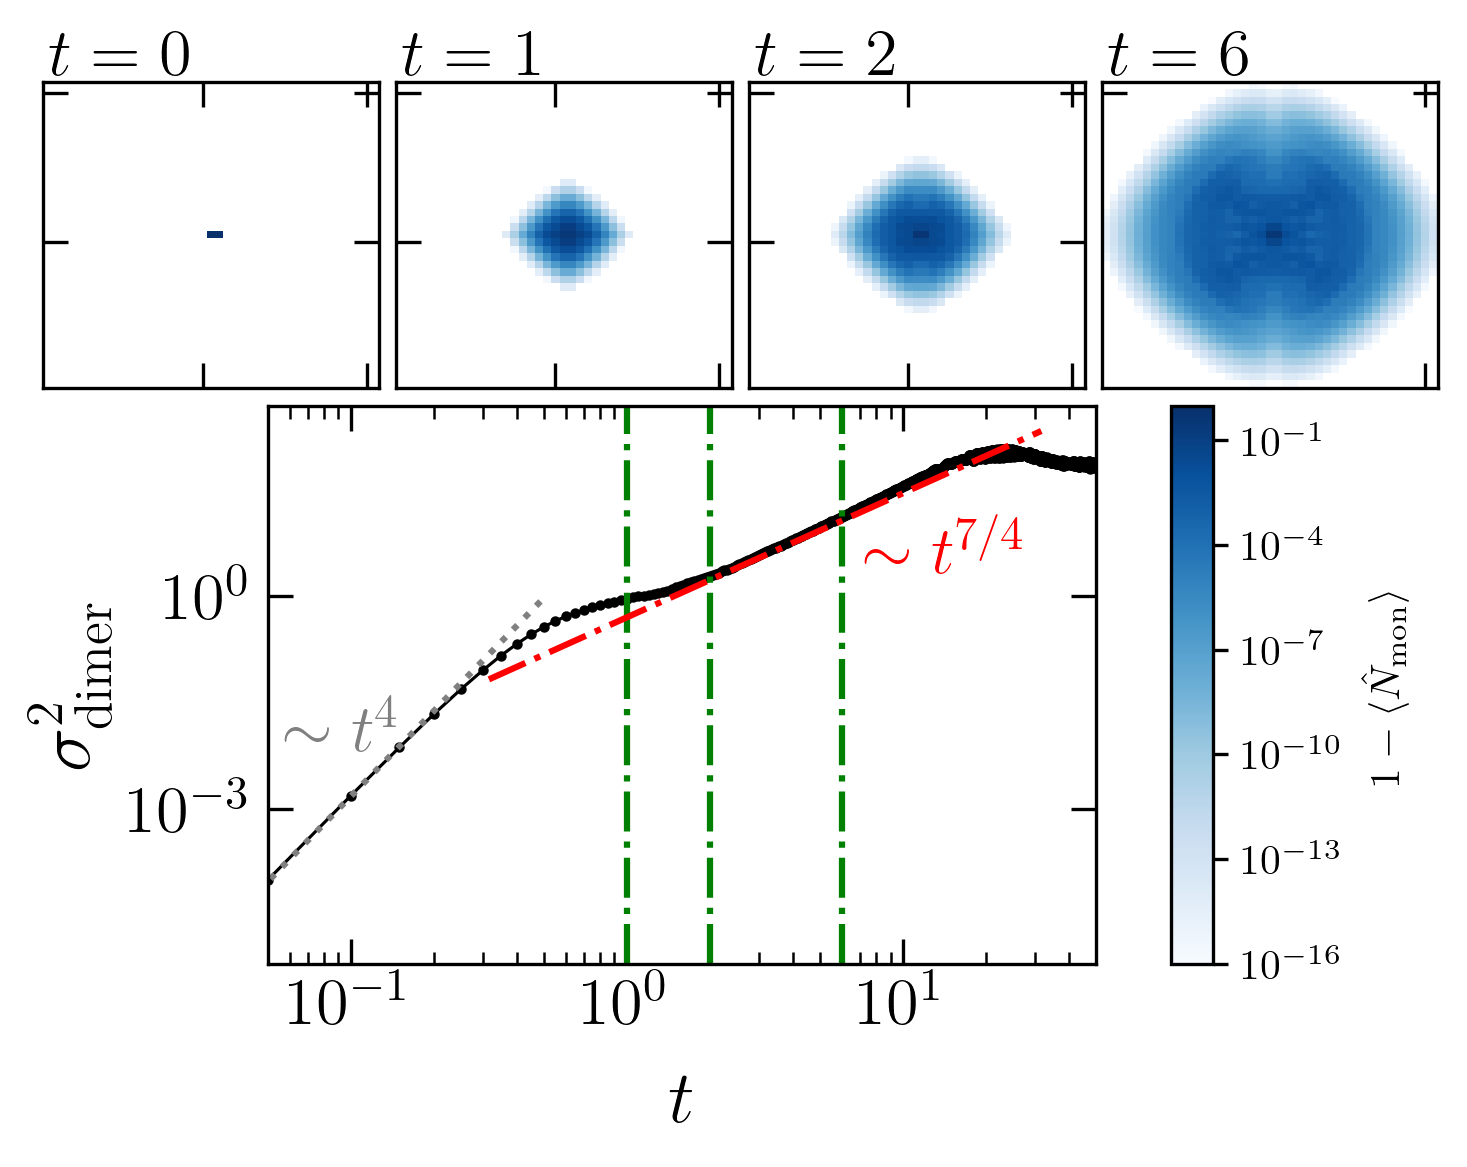

In [278]:

Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1


# fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)
fig = plt.figure(figsize=(6,3), dpi = 300)
gs1 = GridSpec(1, 1)
gs1.update(top=0.64, bottom=0.02, left=0.25, right=0.775)
axis = fig.add_subplot(gs1[0,0])

gs2 = GridSpec(1, 4)
gs2.update(top=1, bottom=0.66, wspace=0.05, hspace=0.05)
ax = []
ax0 = fig.add_subplot(gs2[0]);  ax.append(ax0)
ax1 = fig.add_subplot(gs2[1], sharey = ax0, sharex = ax0); ax.append(ax1)
ax2 = fig.add_subplot(gs2[2], sharey = ax0, sharex = ax0); ax.append(ax2)
ax3 = fig.add_subplot(gs2[3], sharey = ax0, sharex = ax0); ax.append(ax3)
# print( len(ax) )

mass_list = np.arange(-1, 1.1, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

dim = 3 * Lx*Ly
mass = -1

X = np.arange(1, Lx+1, 1)
plot_times = [0, 1, 2, 6]
mass = -1
# for mass in mass_list:
col = s_m.to_rgba(mass)
name = base_dir(BC) + "DimerDynamics_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
if exists(name):
    with h5py.File(name, "r") as file:
        times = np.array(file.get('times'))[0,1:]
        sigma = np.array(file.get('spreading'))[0,1:]
        axis.plot(times, sigma, color='k', marker='o', markersize=1.5, lw=0.75)
        for iit, t in enumerate( plot_times ):
            if t > 0:
                axis.axvline(x=t, color='green', ls='-.')
            n = order_of_magnitude( np.abs(t) )
            Monomers = 1 - np.transpose(np.array(file.get('MonomerDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n)))))
            # print('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n)))
            norms = matplotlib.colors.LogNorm(vmin=np.min(Monomers.flatten()), vmax=np.max(Monomers.flatten()))
            # p = ax[iit].pcolormesh(X, X, Monomers, shading='nearest', cmap='Blues', vmin=np.min(Monomers.flatten()), vmax=np.max(Monomers.flatten()))
            p = ax[iit].pcolormesh(X, X, Monomers, shading='nearest', cmap='Blues', norm=matplotlib.colors.LogNorm(vmin=1e-16, vmax=1))
else:
    print(name)

fig_help.set_plot_elements(axis, ylabel=r"$\sigma^2_{\rm dimer}$", xlabel=r"$t$", font_size=16, set_legend=0, xscale='log', yscale='log')

x = np.logspace(-1.5, -0.3, 1000)
axis.plot(x, 15*x**4, ls=':', color='gray')
axis.annotate(r"$\sim t^4$", fontsize=16, xy=(0.02, 0.38), xycoords='axes fraction', color='gray')

x = np.logspace(-0.5, 1.5, 1000)

# axis.plot(x, 0.8 * x, ls='--', color='black')
# axis.annotate(r"$\sim t$", fontsize=16, xy=(0.35, 0.75), xycoords='axes fraction', color='k')

# x = np.logspace(0., 1., 1000)
axis.plot(x, 0.5 * x**1.75, ls='-.', color='red')
axis.annotate(r"$\sim t^{7/4}$", fontsize=16, xy=(0.72, 0.7), xycoords='axes fraction', color='red')

axis.set_xlim(min(times), max(times))
for iiax, a in enumerate(ax):
    fig_help.set_plot_elements(a, ylabel=r"", xlabel=r"", font_size=14)
    a.tick_params(axis='x', which='both',labelbottom=False,labeltop=False)
    a.tick_params(axis='y', which='both',labelleft=False,labelright=False)
    a.annotate(r"$t=%g$"%plot_times[iiax], fontsize=16, xy=(0.02, 1.02), xycoords='axes fraction', color='k')

divider = make_axes_locatable(axis)  # last axis
cax = divider.append_axes("right", size="5%", pad=0.25)
fig.colorbar(p, cax=cax)#, title=r"$1-\langle \hat{N}_{\rm mon}\rangle$")
cax.set_ylabel(r"$ 1-\langle \hat{N}_{\rm mon}\rangle$")
# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
# cbar.set_label(r"$m$", fontsize=15)
# cbar.ax.tick_params(labelsize=14)

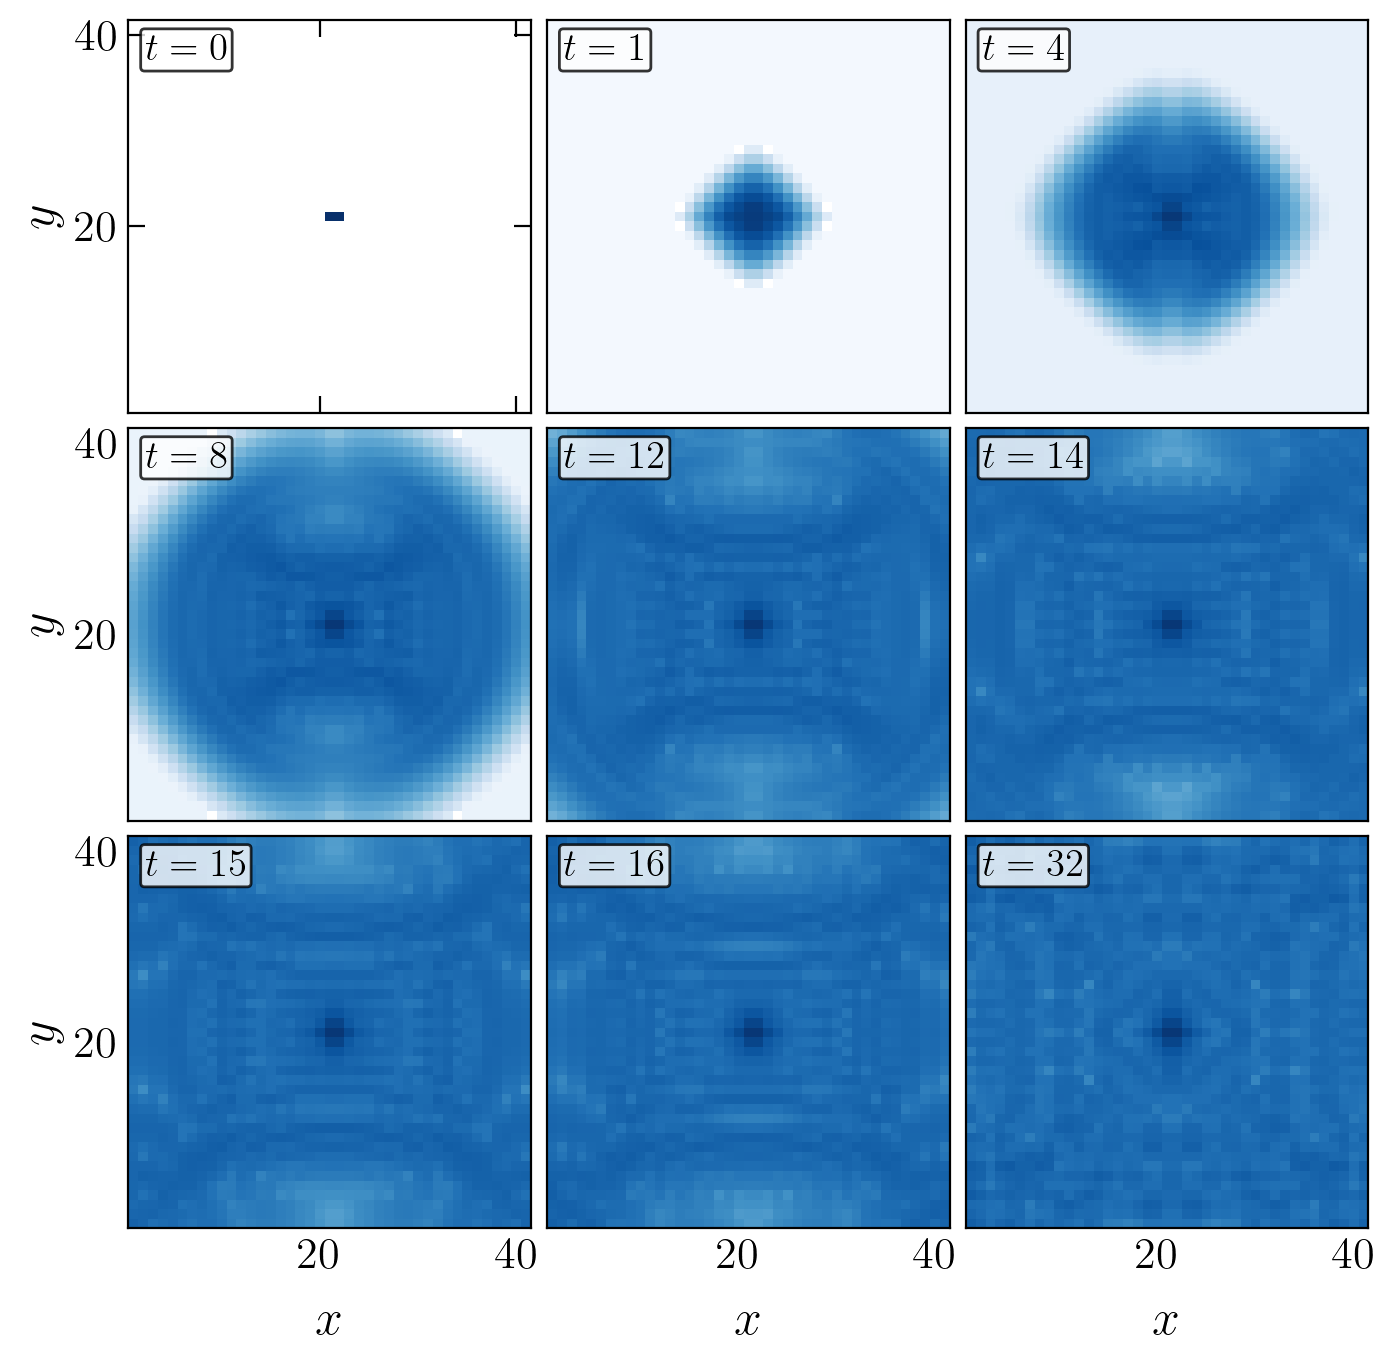

In [274]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1


fig, axis = plt.subplots( nrows=3, ncols=3, figsize=(8,8), dpi = 200, sharex=True, sharey=True)
axis = axis.flatten()
dim = 3 * Lx*Ly
mass = -1

t = 10

X = np.arange(1, Lx+1, 1)

mass_list = np.arange(-1, 0.7, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

mass = 0
name = base_dir(BC) + "DimerDynamics_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
if exists(name):
    with h5py.File(name, "r") as file:
        plot_times = [0, 1, 4, 8, 12, 14, 15, 16, 32]
        for iit, t in enumerate( plot_times ):
            n = order_of_magnitude( np.abs(t) )
            Monomers = np.abs(1 - np.transpose(np.array(file.get('MonomerDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n))))))
            # print(Monomers)
            # SpinDown = np.array(file.get('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n))))
            # print('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n)))
            # norms = matplotlib.colors.LogNorm(vmin=np.min(Monomers.flatten()), vmax=np.max(Monomers.flatten()))
            # print(t, np.min(Monomers.flatten()), np.max(Monomers.flatten()))
            # p = axis[iit].pcolormesh(X, X, Monomers, shading='nearest', cmap='Blues', norm=norms)
            p = axis[iit].pcolormesh(X, X, Monomers, shading='nearest', cmap='Blues', norm=matplotlib.colors.LogNorm(vmin=1e-16, vmax=1))
            fig_help.set_plot_elements(axis[iit], ylabel=r"$y$" if iit%3 ==0 else "", xlabel=r"$x$" if iit >5 else "", font_size=16, set_legend=0, xscale='linear', yscale='linear')
else:
    print(name)


for iiax, a in enumerate(axis):
    t = plot_times[iiax]
    # a.annotate(r"$t=%g$"%t, fontsize=12, xy=(0.02, 0.93), xycoords='axes fraction', color='k')
    a.annotate(r"$t=%g$"%plot_times[iiax], 
           fontsize=14, 
           xy=(0.04, 0.9), 
           xycoords='axes fraction', 
           color='k',
           bbox=dict(boxstyle="round,pad=0.1", 
                     facecolor='white', 
                     edgecolor='black', 
                     alpha=0.8))
    
# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
# cbar.set_label(r"$m$", fontsize=15)
# cbar.ax.tick_params(labelsize=14)

fig.subplots_adjust(wspace = 0.04, hspace=0.04)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


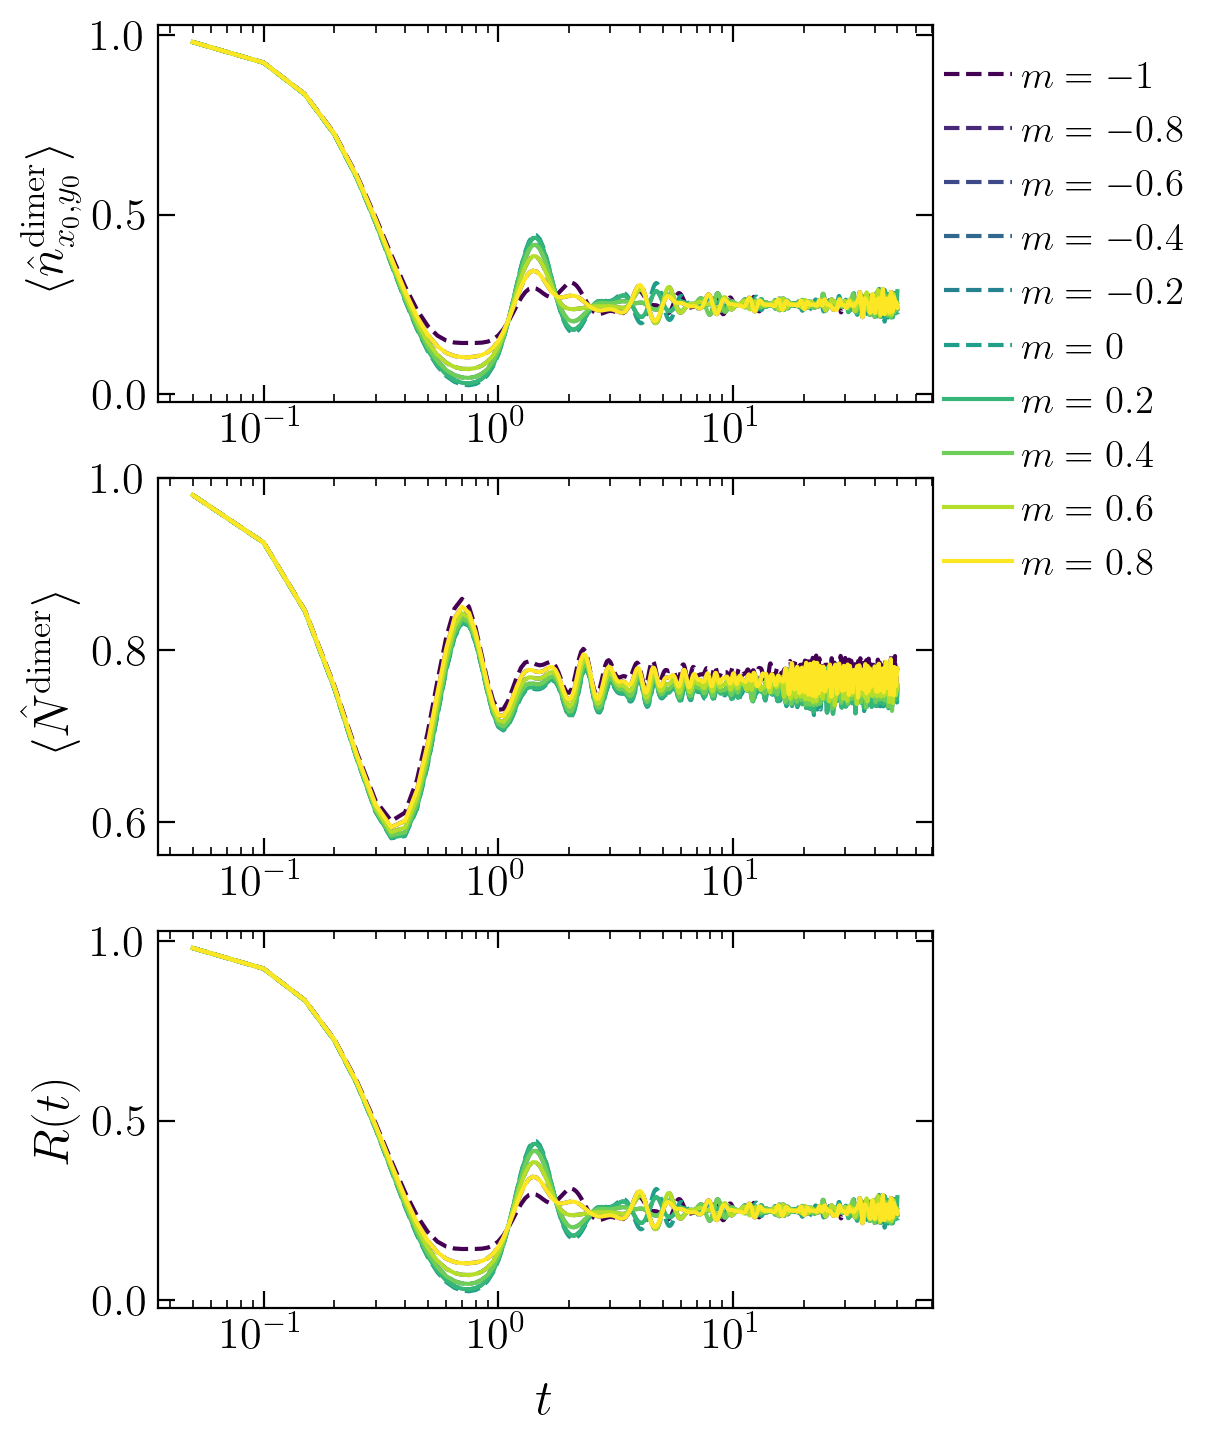

In [221]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1

mass_list = np.arange(-1, 0.9, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=3, ncols=1, figsize=(5,8.5), dpi = 200)

dim = 3 * Lx*Ly

for iim, mass in enumerate( mass_list ):
    col = s_m.to_rgba(mass)
    name = base_dir(BC) + "DimerDynamics_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
    if exists(name):
        with h5py.File(name, "r") as file:
            
            times = np.array(file.get('times'))[0,1:]
            return_probability = np.array(file.get('return_probability'))[0,1:]
            axis[2].plot(times, return_probability, color=col, ls='-' if mass > 0 else '--')
            
            SpinDownNumber = np.array(file.get('DimerDensity'))[0,1:] / 2
            axis[1].plot(times, Lx*Ly * SpinDownNumber, color=col, ls='-' if mass > 0 else '--')
            # SpinUpNumber = np.array(file.get('MonomerDensity'))[0,1:] - SpinDownNumber
            # axis[1].plot(times, Lx*Ly * SpinUpNumber / (Lx*Ly-1), color=col, ls='--')
            # SpinDimerCenterDensity
            SpinDimerCenterDensity = np.array(file.get('DimerCenterDensity'))[0,1:]
            # plot_times = np.arange(0, max(times), 0.2)
            # spindown_density = np.zeros(plot_times.shape)
            # for iit, t in enumerate( plot_times ):
            #     spindown_density[0] = 1
            #     if t > 0:
            #         n = order_of_magnitude( np.abs(t) )
            #         spindown_density[iit] = np.array(file.get('SpinDownDensity_snapshot/t = ' + str("{:.%df}"%(n)).format(round(np.abs(t), n))))[Ly//2, Lx//2]
            axis[0].plot(times, SpinDimerCenterDensity, color=col, ls='-' if mass > 0 else '--', label=r"$m=%g$"%mass if np.abs(mass) > 1e-14 else r"$m=0$")
    else:   
        print(name)

fig_help.set_plot_elements(axis[0], ylabel=r"$\langle \hat{n}^{\rm dimer}_{x_0,y_0}\rangle$", xlabel=r"", font_size=16, set_legend=1, xscale='log', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"$\langle \hat{N}^{\rm dimer}\rangle$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='linear')
fig_help.set_plot_elements(axis[2], ylabel=r"$R(t)$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='linear')

fig_help.set_legend(axis[0], fontsize=14, loc='upper left', anchor=(0.97, 1.0), frameon=False)
# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
# cbar.set_label(r"$m$", fontsize=15)
# cbar.ax.tick_params(labelsize=14)

(0.01, 100.0)

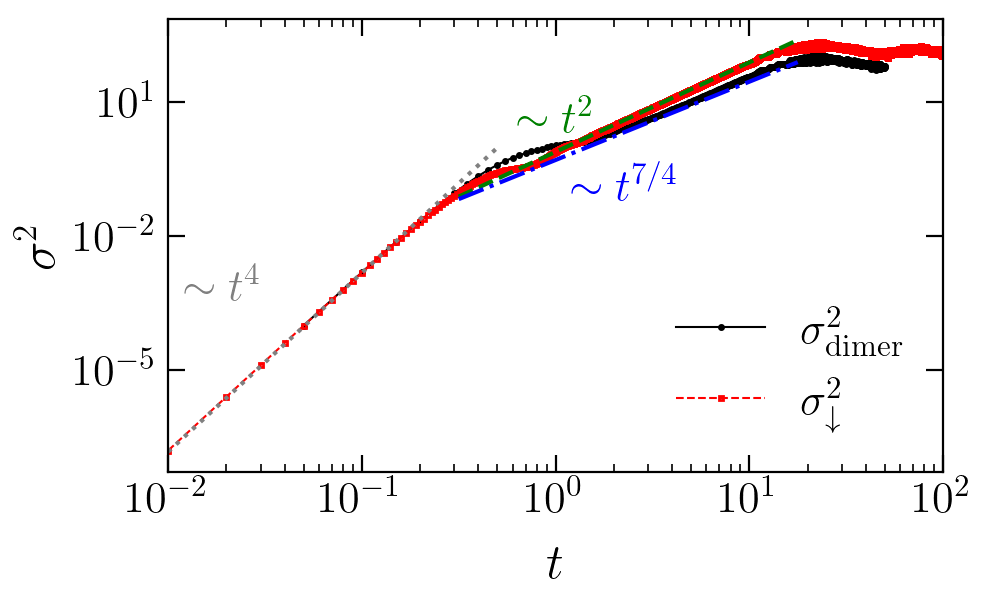

In [222]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)
# fig = plt.figure(figsize=(6,3), dpi = 300)
# gs1 = GridSpec(1, 1)
# gs1.update(top=0.64, bottom=0.02, left=0.25, right=0.75)
# axis = fig.add_subplot(gs1[0,0])

# gs2 = GridSpec(1, 4)
# gs2.update(top=1, bottom=0.66, wspace=0.05, hspace=0.05)
# ax = []
# ax0 = fig.add_subplot(gs2[0]);  ax.append(ax0)
# ax1 = fig.add_subplot(gs2[1], sharey = ax0, sharex = ax0); ax.append(ax1)
# ax2 = fig.add_subplot(gs2[2], sharey = ax0, sharex = ax0); ax.append(ax2)
# ax3 = fig.add_subplot(gs2[3], sharey = ax0, sharex = ax0); ax.append(ax3)
# print( len(ax) )

mass_list = np.arange(-1, 1.1, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

dim = 3 * Lx*Ly
mass = -1

X = np.arange(1, Lx+1, 1)
# plot_times = [0, 0.2, 2, 6.0]
mass = 0

name = base_dir(BC) + "DimerDynamics_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
if exists(name):
    with h5py.File(name, "r") as file:
        times = np.array(file.get('times'))[0,1:]
        sigma = np.array(file.get('spreading'))[0,1:]
        axis.plot(times, sigma, color='k', marker='o', markersize=1.5, lw=0.75, label=r"$\sigma^2_{\rm dimer}$")
else:
    print(name)
name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
if exists(name):
    with h5py.File(name, "r") as file:
        times = np.array(file.get('times'))[0,1:]
        sigma = np.array(file.get('spreading'))[0,1:]
        axis.plot(times, sigma, color='red', marker='s', ls='--', markerfacecolor='None', markersize=1.5, lw=0.75, label=r"$\sigma^2_{\downarrow}$")
        
fig_help.set_plot_elements(axis, ylabel=r"$\sigma^2$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')

x = np.logspace(-2, -0.3, 1000)
axis.plot(x, 15*x**4, ls=':', color='gray')
axis.annotate(r"$\sim t^4$", fontsize=16, xy=(0.02, 0.38), xycoords='axes fraction', color='gray')

x = np.logspace(-0.5, 1.25, 1000)

axis.plot(x, 0.76 * x**2, ls='--', color='green')
axis.annotate(r"$\sim t^2$", fontsize=16, xy=(0.45, 0.75), xycoords='axes fraction', color='green')

# x = np.logspace(0., 1., 1000)
axis.plot(x, 0.5 * x**1.75, ls='-.', color='blue')
axis.annotate(r"$\sim t^{7/4}$", fontsize=16, xy=(0.52, 0.6), xycoords='axes fraction', color='blue')

axis.set_xlim(min(times), max(times))
# for iiax, a in enumerate(ax):
#     fig_help.set_plot_elements(a, ylabel=r"", xlabel=r"", font_size=14)
#     a.tick_params(axis='x', which='both',labelbottom=False,labeltop=False)
#     a.tick_params(axis='y', which='both',labelleft=False,labelright=False)
#     a.annotate(r"$t=%g$"%plot_times[iiax], fontsize=16, xy=(0.02, 1.02), xycoords='axes fraction', color='k')
    
# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
# cbar.set_label(r"$m$", fontsize=15)
# cbar.ax.tick_params(labelsize=14)

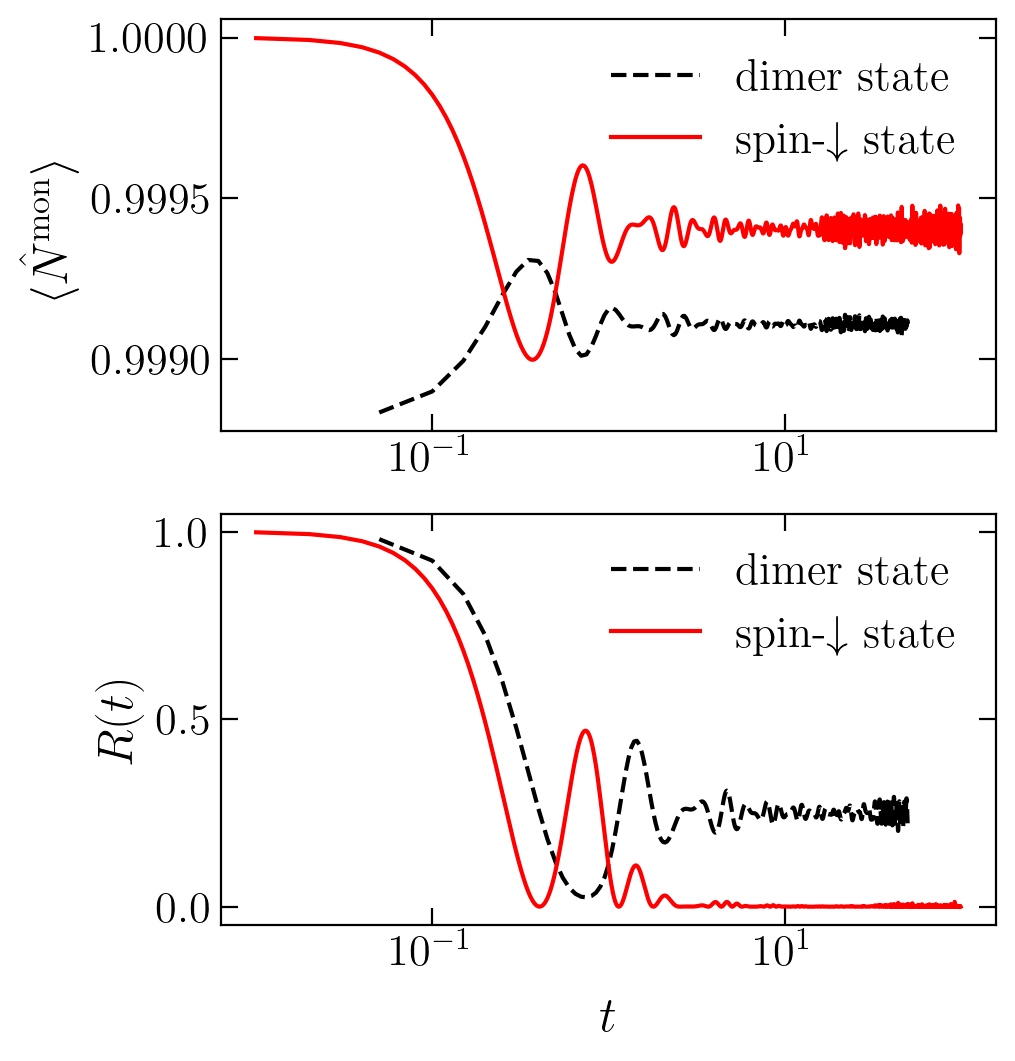

In [265]:
Lx = 41
Ly = Lx
Nu = -1
Nd = 1
tau = 1
mass = 0
BC = 1 #PBC: BC=1

mass_list = np.arange(-1, 0.9, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(mass_list),
                vmax=max(mass_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(5,6), dpi = 200)

dim = 3 * Lx*Ly
mass = 0

name = base_dir(BC) + "DimerDynamics_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
if exists(name):
    with h5py.File(name, "r") as file:
        times = np.array(file.get('times'))[0,1:]
        return_probability = np.array(file.get('return_probability'))[0,1:]
        axis[1].plot(times, return_probability, color='k', ls='--', label=r"dimer state")
        
        MonomerDensity = np.array(file.get('MonomerDensity'))[0,1:]
        axis[0].plot(times, MonomerDensity, color='k', ls='--', label=r"dimer state")
    
else:   
    print(name)
    
    
name = base_dir(BC) + "SpinImpurity_Test/" + info(Lx, Ly, Nu, Nd, tau, mass)
if exists(name):
    with h5py.File(name, "r") as file:
        times = np.array(file.get('times'))[0,1:]
        return_probability = np.array(file.get('return_probability'))[0,1:]
        axis[1].plot(times, return_probability, color='red', ls='-', label=r"spin-$\downarrow$ state")
        
        MonomerDensity = np.array(file.get('MonomerDensity'))[0,1:]
        axis[0].plot(times, MonomerDensity, color='red', ls='-', label=r"spin-$\downarrow$ state")
    
else:   
    print(name)

fig_help.set_plot_elements(axis[0], ylabel=r"$\langle \hat{N}^{\rm mon}\rangle$", xlabel=r"", font_size=16, set_legend=1, xscale='log', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"$R(t)$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='linear')
